## DebtRank Stress Testing under Counterparty Default Contagion

- Author: Abbinav Sankar Kailasam
- Project: Systemic Risk in Interbank Networks: DebtRank Stress Testing under Counterparty Default and Overlapping Portfolio Contagion

In [26]:
# Importing necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

import networkx as nx

In [27]:
equities_raw = pd.read_csv("data/bankEquities.csv", header=None)
exposures_raw = pd.read_csv("data/interbankExposures.csv", header=None)

equity = equities_raw.values.flatten().astype(float)
L = exposures_raw.values.astype(float)

N = len(equity)
print(f"Number of banks          : {N}")
print(f"Non-zero exposure links  : {(L > 0).sum()}")
print(f"Equity  — min: {equity.min():>12,.1f}  max: {equity.max():>16,.1f}")
print(f"Exposure— min: {L.min():>12,.1f}  max: {L.max():>16,.1f}")

Number of banks          : 145
Non-zero exposure links  : 6191
Equity  — min:      3,008.6  max:    168,110,000.0
Exposure— min:          0.0  max:     51,644,000.0


In [28]:
W = np.zeros((N, N))
for i in range(N):
    if equity[i] > 0:
        W[i, :] = L[i, :] / equity[i]
W = np.minimum(W, 1.0)

print(f"W max value (pre-cap)    : {(L / equity[:, None]).max():.4f}")
print(f"W max value (post-cap)   : {W.max():.4f}")
print(f"W mean (non-zero entries): {W[W>0].mean():.6f}")

W max value (pre-cap)    : 6.5841
W max value (post-cap)   : 1.0000
W mean (non-zero entries): 0.098421


In [29]:
def run_debtrank(W_eff, equity, initial_shock_idx, shock_magnitude=1.0):
    N = len(equity)
    h = np.zeros(N)
    status = np.zeros(N, dtype=int)

    for idx in initial_shock_idx:
        h[idx]      = shock_magnitude
        status[idx] = 1

    h_history = [h.copy()]
    total_equity = equity.sum()

    for t in range(1000):
        h_new    = h.copy()
        converged = True

        for i in range(N):
            if status[i] != 0:
                continue
            contribution = 0.0
            for j in range(N):
                if status[j] == 1:   # j is Distressed
                    contribution += W_eff[j, i] * h[j]
            candidate = h[i] + contribution
            new_h_i   = min(candidate, 1.0)
            if new_h_i > h_new[i] + 1e-12:
                h_new[i] = new_h_i
                converged = False

        for i in range(N):
            if status[i] == 1:
                status[i] = 2   # Inactive

        for i in range(N):
            if status[i] == 0 and h_new[i] > 1e-12:
                status[i] = 1

        h = h_new
        h_history.append(h.copy())

        if converged:
            break

    h0 = np.zeros(N)
    for idx in initial_shock_idx:
        h0[idx] = shock_magnitude

    SL = np.sum(equity * (h - h0)) / total_equity
    return h, max(SL, 0.0), t + 1, np.array(h_history)

In [30]:
total_outgoing = L.sum(axis=1)
total_incoming = L.sum(axis=0)

largest_bank = int(np.argmax(total_outgoing))
top5_banks   = list(np.argsort(total_outgoing)[-5:][::-1])

rng          = np.random.default_rng(seed=42)
random_bank  = int(rng.integers(0, N))

print(f"Largest bank (by outgoing exposure) : Bank {largest_bank}")
print(f"Top-5 most exposed banks            : {top5_banks}")
print(f"Random bank                         : Bank {random_bank}")

R_baseline = 0.4

Largest bank (by outgoing exposure) : Bank 128
Top-5 most exposed banks            : [np.int64(128), np.int64(3), np.int64(7), np.int64(82), np.int64(83)]
Random bank                         : Bank 12


In [31]:
W_eff_baseline = W * (1 - R_baseline)

h_A, SL_A, rounds_A, hist_A = run_debtrank(W_eff_baseline, equity, [largest_bank])
h_B, SL_B, rounds_B, hist_B = run_debtrank(W_eff_baseline, equity, top5_banks)
h_C, SL_C, rounds_C, hist_C = run_debtrank(W_eff_baseline, equity, [random_bank])

print(f"Scenario A (largest bank default)       → SL = {SL_A*100:.2f}%  ({rounds_A} rounds)")
print(f"Scenario B (top-5 simultaneous)         → SL = {SL_B*100:.2f}%  ({rounds_B} rounds)")
print(f"Scenario C (random bank {random_bank:3d}, seed=42) → SL = {SL_C*100:.2f}%  ({rounds_C} rounds)")

Scenario A (largest bank default)       → SL = 15.85%  (3 rounds)
Scenario B (top-5 simultaneous)         → SL = 37.86%  (3 rounds)
Scenario C (random bank  12, seed=42) → SL = 16.52%  (3 rounds)


In [32]:
MC_SL = np.array([run_debtrank(W_eff_baseline, equity, [i])[1] for i in range(N)])

print(f"Mean SL across all random draws  : {MC_SL.mean()*100:.3f}%")
print(f"Median SL                        : {np.median(MC_SL)*100:.3f}%")
print(f"Std  SL                          : {MC_SL.std()*100:.3f}%")
print(f"Min  SL  (Bank {int(np.argmin(MC_SL)):3d})            : {MC_SL.min()*100:.3f}%")
print(f"Max  SL  (Bank {int(np.argmax(MC_SL)):3d})            : {MC_SL.max()*100:.3f}%")
print(f"P25 / P75                        : {np.percentile(MC_SL,25)*100:.3f}% / {np.percentile(MC_SL,75)*100:.3f}%")

Mean SL across all random draws  : 12.847%
Median SL                        : 11.716%
Std  SL                          : 9.287%
Min  SL  (Bank   0)            : 0.000%
Max  SL  (Bank  35)            : 45.509%
P25 / P75                        : 5.592% / 18.417%


In [33]:
R_values = np.linspace(0, 1, 100)
SL_A_vs_R = []
SL_B_vs_R = []
SL_C_vs_R = []

for R in R_values:
    W_eff = W * (1 - R)
    _, sl_a, _, _ = run_debtrank(W_eff, equity, [largest_bank])
    _, sl_b, _, _ = run_debtrank(W_eff, equity, top5_banks)
    _, sl_c, _, _ = run_debtrank(W_eff, equity, [random_bank])
    SL_A_vs_R.append(sl_a)
    SL_B_vs_R.append(sl_b)
    SL_C_vs_R.append(sl_c)

print(f"Sweep complete: {len(R_values)} recovery rate values")

Sweep complete: 100 recovery rate values


In [34]:
DR_scores = MC_SL   # already computed in Step 4b — reuse directly
top10_idx = np.argsort(DR_scores)[-10:][::-1]

print("  Top-10 systemically important banks (by DebtRank score):")
for rank, idx in enumerate(top10_idx, 1):
    print(f"    {rank:2d}. Bank {idx:3d}  →  DebtRank = {DR_scores[idx]*100:.3f}%")

  Top-10 systemically important banks (by DebtRank score):
     1. Bank  35  →  DebtRank = 45.509%
     2. Bank  90  →  DebtRank = 44.594%
     3. Bank  49  →  DebtRank = 41.498%
     4. Bank  50  →  DebtRank = 34.369%
     5. Bank  24  →  DebtRank = 33.424%
     6. Bank  74  →  DebtRank = 32.449%
     7. Bank  19  →  DebtRank = 30.307%
     8. Bank 101  →  DebtRank = 30.220%
     9. Bank 127  →  DebtRank = 28.822%
    10. Bank 138  →  DebtRank = 28.267%


In [35]:
G = nx.DiGraph()
G.add_nodes_from(range(N))
for i in range(N):
    for j in range(N):
        if L[i, j] > 0:
            G.add_edge(i, j, weight=L[i, j])

In [36]:
# fig, ax = plt.subplots(figsize=(10, 8))
# pos = nx.kamada_kawai_layout(G)

# edges    = list(G.edges())
# eweights = np.array([G[u][v]["weight"] for u, v in edges])
# ealpha   = 0.05 + 0.6 * (eweights / eweights.max())

# for (u, v), alpha in zip(edges, ealpha):
#     nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], edge_color="steelblue", alpha=float(alpha), arrows=True, arrowsize=8, arrowstyle="-|>", width=0.6, connectionstyle="arc3,rad=0.1")

# norm      = mcolors.Normalize(vmin=0, vmax=DR_scores.max())
# cmap      = plt.cm.get_cmap("winter")
# node_cols = [cmap(norm(DR_scores[i])) for i in range(N)]

# nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_cols, node_size=80, alpha=0.95, edgecolors="black", linewidths=0.3)

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
# cbar.set_label("DebtRank Score", fontsize=12)

# ax.set_title("Interbank Exposure Network with DebtRank Scores", fontsize=14)
# ax.axis("off")
# plt.tight_layout()
# plt.savefig("outputs/fig1_intrbnk_exp_debtrank_part1.png", dpi=300, bbox_inches="tight", facecolor="white")

# plt.show()

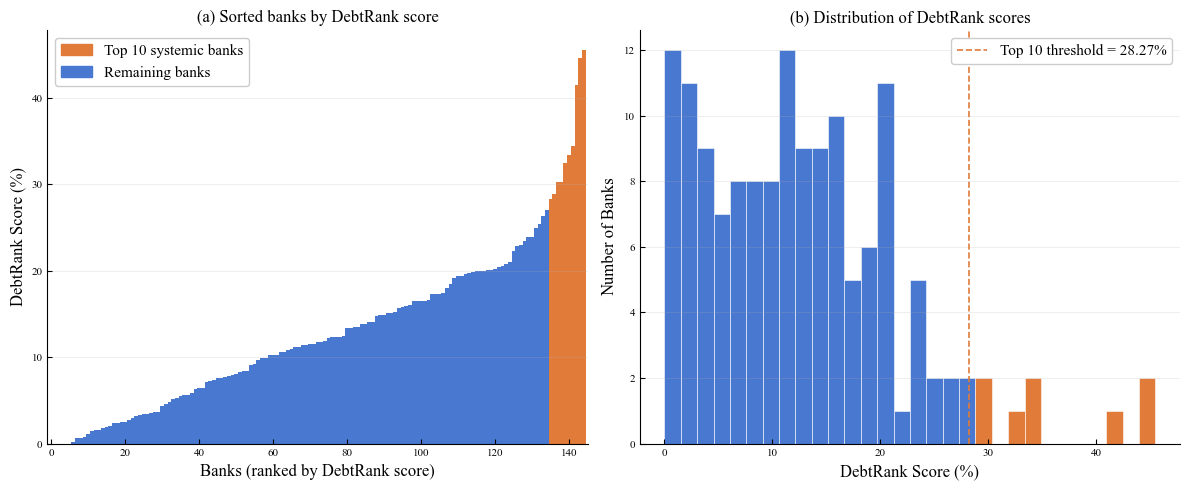

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sorted_idx    = np.argsort(DR_scores)
sorted_scores = DR_scores[sorted_idx] * 100

bar_cols = ["#e07b39" if i in top10_idx else "#4878cf" for i in sorted_idx]
ax.bar(np.arange(N), sorted_scores, color=bar_cols, width=1.0, linewidth=0)
ax.set_xlabel("Banks (ranked by DebtRank score)", fontsize=12)
ax.set_ylabel("DebtRank Score (%)", fontsize=12)
ax.set_title("(a) Sorted banks by DebtRank score", fontsize=12)
ax.set_xlim(-1, N)
ax.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(direction="in", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
p1 = mpatches.Patch(color="#e07b39", label="Top 10 systemic banks")
p2 = mpatches.Patch(color="#4878cf", label="Remaining banks")
ax.legend(handles=[p1, p2], fontsize=11, framealpha=1.0, edgecolor="#cccccc")

ax2 = axes[1]
threshold_dr = DR_scores[top10_idx[-1]] * 100
counts, bins, patches = ax2.hist(DR_scores * 100, bins=30, edgecolor="white", linewidth=0.4)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor("#e07b39" if left >= threshold_dr else "#4878cf")

ax2.axvline(threshold_dr, color="#e07b39", lw=1.2, ls="--", label=f"Top 10 threshold = {threshold_dr:.2f}%")
ax2.set_xlabel("DebtRank Score (%)", fontsize=12)
ax2.set_ylabel("Number of Banks", fontsize=12)
ax2.set_title("(b) Distribution of DebtRank scores", fontsize=12)
ax2.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax2.tick_params(direction="in", labelsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=11, framealpha=1.0, edgecolor="#cccccc")

plt.tight_layout()
plt.show()

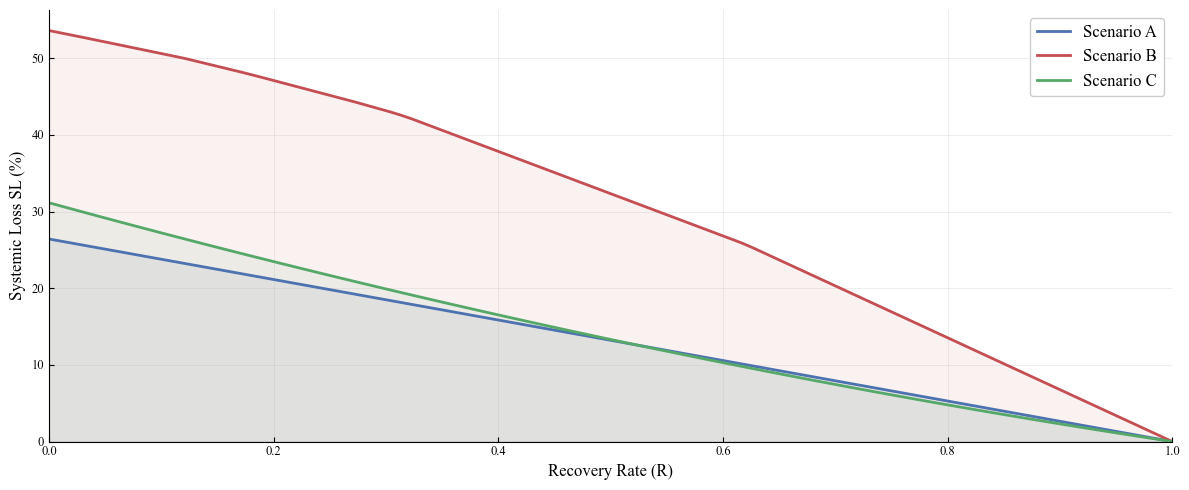

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(R_values, np.array(SL_A_vs_R) * 100, color="#4c72b0", lw=2, label=f"Scenario A")
ax.plot(R_values, np.array(SL_B_vs_R) * 100, color="#c44e52", lw=2, label="Scenario B")
ax.plot(R_values, np.array(SL_C_vs_R) * 100, color="#55a868", lw=2, label=f"Scenario C")

ax.fill_between(R_values, np.array(SL_A_vs_R) * 100, alpha=0.08, color="#4c72b0")
ax.fill_between(R_values, np.array(SL_B_vs_R) * 100, alpha=0.08, color="#c44e52")
ax.fill_between(R_values, np.array(SL_C_vs_R) * 100, alpha=0.08, color="#55a868")

ax.set_xlabel("Recovery Rate (R)", fontsize=12)
ax.set_ylabel("Systemic Loss SL (%)", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0)
ax.tick_params(direction="in", labelsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(fontsize=12, framealpha=1.0, edgecolor="#cccccc")

plt.tight_layout()
plt.show()

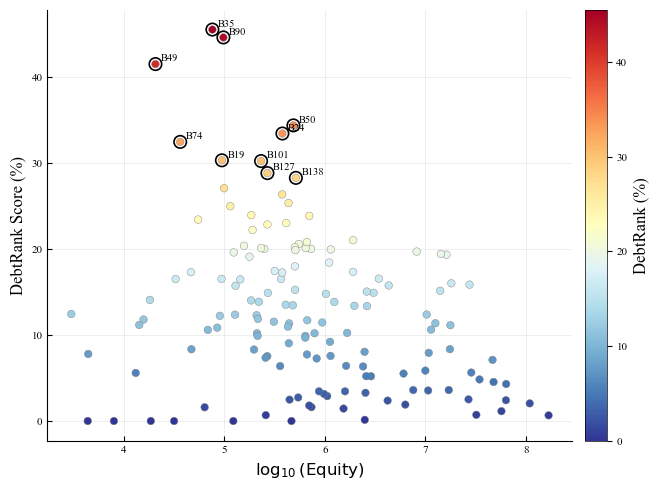

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))

log_eq = np.log10(equity)
sc = ax.scatter(log_eq, DR_scores * 100, c=DR_scores * 100, cmap="RdYlBu_r", s=30, alpha=1, linewidths=0.3, edgecolors="grey", zorder=2)

for idx in top10_idx:
    ax.scatter(log_eq[idx], DR_scores[idx] * 100, s=80, facecolors="none", edgecolors="black", linewidths=1.2, zorder=3)
    ax.annotate(f"B{idx}", xy=(log_eq[idx], DR_scores[idx] * 100), xytext=(4, 2), textcoords="offset points", fontsize=7.5)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("DebtRank (%)", fontsize=12)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_linewidth(0.5)

ax.set_xlabel(r"$\log_{10}(\mathrm{Equity})$", fontsize=12)
ax.set_ylabel("DebtRank Score (%)", fontsize=12)
ax.tick_params(direction="in", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()